<a href="https://colab.research.google.com/github/kanakagrawal23/Fresh-vs-Rotten-Apple-Classifier/blob/main/Fresh_vs_Rotten_Apple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
with zipfile.ZipFile("apple.zip", 'r') as file:
  file.extractall()

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import os

In [4]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 8

TRAIN_DIR = "/content/dataset/Train"
TEST_DIR = "/content/dataset/Test"

In [5]:
train_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [6]:
base_model = MobileNetV2(
    input_shape = (224,224,3),
    include_top = False,
    weights = "imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(12, activation = "relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation = "sigmoid" )
])

In [8]:
model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [9]:
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

Found 5672 files belonging to 2 classes.
Found 1779 files belonging to 2 classes.


In [10]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x,y: (normalization_layer(x),y))
test_data = test_data.map(lambda x,y: (normalization_layer(x), y))

In [11]:
train_data = train_data.map(
    lambda x, y : (train_augmentation( x, training = True), y)
)

In [12]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(buffer_size = AUTOTUNE)
test_data = test_data.prefetch(buffer_size = AUTOTUNE)

In [13]:
history = model.fit(
    train_data,
    validation_data = test_data,
    epochs = EPOCHS
)

Epoch 1/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 123s 579ms/step - accuracy: 0.8868 - loss: 0.2758 - val_accuracy: 0.9843 - val_loss: 0.0486
Epoch 2/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 423ms/step - accuracy: 0.9795 - loss: 0.0682 - val_accuracy: 0.9876 - val_loss: 0.0368
Epoch 3/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 426ms/step - accuracy: 0.9844 - loss: 0.0451 - val_accuracy: 0.9921 - val_loss: 0.0259
Epoch 4/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 425ms/step - accuracy: 0.9873 - loss: 0.0391 - val_accuracy: 0.9916 - val_loss: 0.0204
Epoch 5/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 425ms/step - accuracy: 0.9902 - loss: 0.0287 - val_accuracy: 0.9916 - val_loss: 0.0178
Epoch 6/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 77s 429ms/step - accuracy: 0.9927 - loss: 0.0236 - val_accuracy: 0.9961 - val_loss: 0.0154
Epoch 7/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 77s 429ms/step - accuracy: 0.9903 - loss: 0.0248 - val_accuracy: 0.9955 - val_loss: 0.0188
Epoch 8/8
178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 425ms/step - accuracy: 0.9919 - loss: 0.0201 -

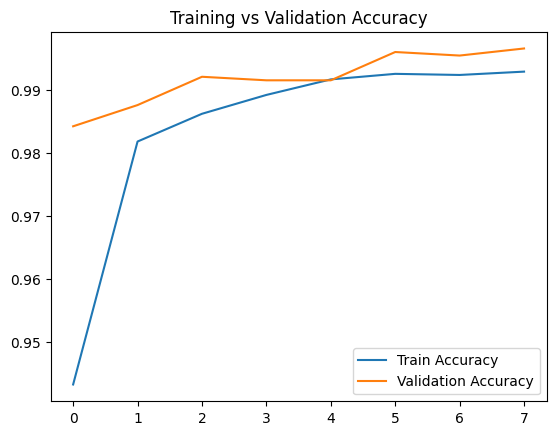

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [15]:
from google.colab import files
uploaded = files.upload()

Saving a_r029.png to a_r029.png


In [16]:
image_path = list(uploaded.keys())[0]

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(image_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = img_array / 255.0   # normalize
img_array = np.expand_dims(img_array, axis=0)

In [18]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [19]:
if prediction[0][0] > 0.5:
    print("Rotten")
else:
    print("Fresh")

Rotten


In [20]:
confidence = prediction[0][0]
print(f"Confidence: {confidence:.2f}")

Confidence: 1.00


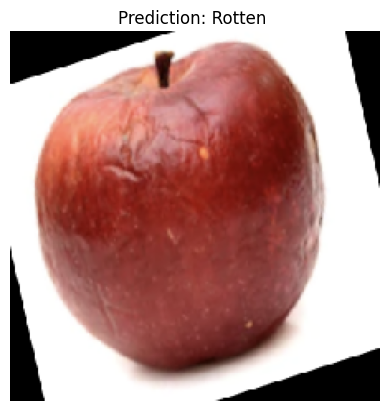

In [21]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")
plt.title("Prediction: Rotten " if prediction[0][0] > 0.5 else "Prediction: Fresh")
plt.show()

In [ ]:
# model.save("apple_fresh_rotten_model.h5")

In [ ]:
# from google.colab import files
# files.download("apple_fresh_rotten_model.h5")

In [ ]:
# model.save("apple_fresh_rotten_model.keras")


In [ ]:
# from google.colab import files
# files.download("apple_fresh_rotten_model.keras")